# Bitcoin hourly return prediction: models and hyperparameters

This notebook picks up where `data-preparation.ipynb` ends. It expects these variables to exist:
`X_train, X_test` (shape `(n, 168, 6)`), `y_train, y_test` (shape `(n, 24)`), `dates_train, dates_test`, `feature_cols`, `INPUT_HOURS`, `TARGET_HOURS`.

**Task:** given the last 168 hours (1 week), predict the 24 hourly returns of the next day.

**Plan**
1. Small model-side feature step (turn each 168×6 window into a compact, scale-free feature vector).
2. Evaluation helpers and simple baselines. Every model has to beat these to be interesting.
3. Models, each with a small hyperparameter sweep on a validation set:
   Ridge / Lasso (linear), k-Nearest Neighbors, Random Forest, Gradient Boosting, and (optional) a small MLP.
4. A more rigorous tuning example with `TimeSeriesSplit` + `GridSearchCV`.
5. Final comparison on the test set.

**A realistic expectation:** short-term crypto returns are very close to random noise. It is completely normal if the "predict zero" baseline has the lowest MAE and the models land around 50–53% directional accuracy. The learning goal is to compare models and see how hyperparameters change their behaviour (over/underfitting), not to beat the market.

## 0. Load the prepared data

Path to dataset files: /home/alberto/.cache/kagglehub/datasets/mczielinski/bitcoin-historical-data/versions/740
<class 'pandas.DataFrame'>
RangeIndex: 7758900 entries, 0 to 7758899
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  int64  
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(5), int64(1)
memory usage: 355.2 MB


findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


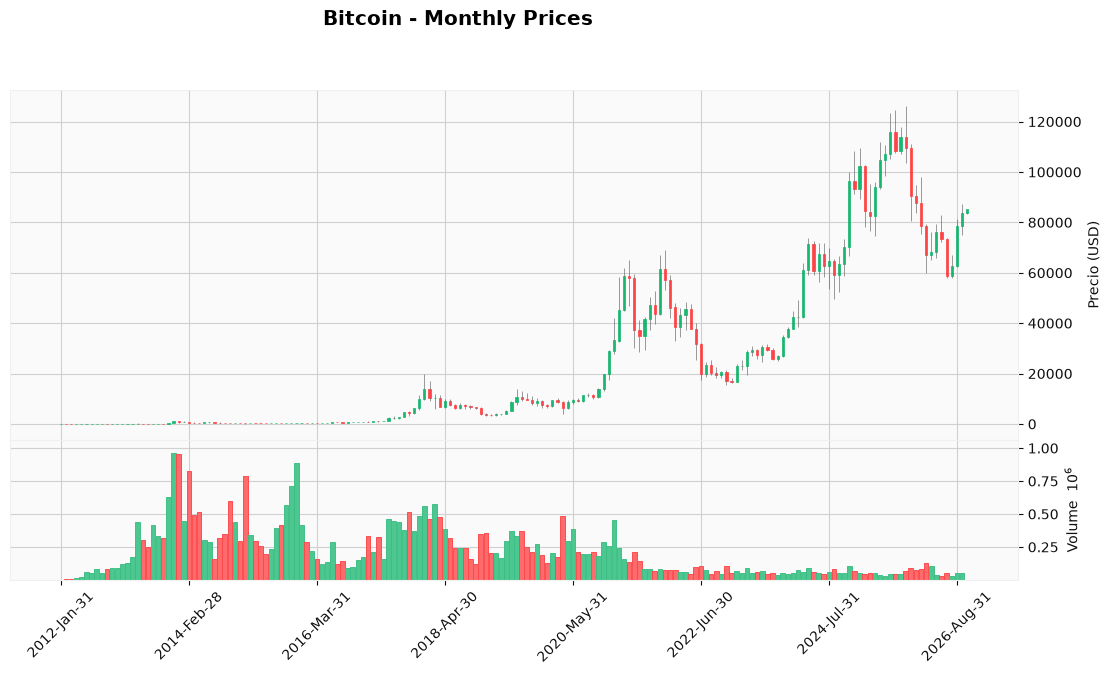

Total samples generated: 129124
Shape of X: (129124, 168, 6)
Shape of y: (129124, 24)
Train: 103299 samples (2012-01-09 00:00:00 -> 2023-10-22 02:00:00)
Test:  25825 samples (2023-10-22 03:00:00 -> 2026-10-02 03:00:00)


In [1]:
# Runs the team's data preparation notebook (put it in the same folder as this one).
# It downloads the data from Kaggle and creates X_train, X_test, y_train, y_test, ...
%run ./data-preparation.ipynb

In [3]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

RANDOM_STATE = 42
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test: ", X_test.shape,  " y_test: ", y_test.shape)

X_train: (103299, 168, 6)  y_train: (103299, 24)
X_test:  (25825, 168, 6)  y_test:  (25825, 24)


## 1. Model-side feature preparation

The raw windows contain absolute prices (Open/High/Low/Close) that range from about 5 in 2012 to more than 100,000 today. Classical ML models (linear, trees, KNN) cannot generalise from a 2015 price level to a 2025 price level, so we feed them **scale-free** information instead. We do not change the team's data preparation; we only transform the windows right before modelling.

Two feature sets are available (switch with `FEATURE_SET`):

- `"engineered"` (default, ~38 features): last 24 hourly returns, rolling mean/volatility of returns over 24h/72h/168h, 24h and 168h cumulative return, where the last close sits in the week's high–low range, average hourly high–low range, and a volume ratio.
- `"returns_only"` (168 features): just the 168 hourly returns of the window, flattened.

Two more practical settings:

- `STRIDE`: consecutive windows overlap by 167 hours, so they are almost duplicates. Keeping every 6th window makes training ~6× faster with very little information lost.
- `TRAIN_START`: optionally drop the early years (2012–2016), when the market was tiny and much more erratic. Try `None` vs `"2017-01-01"` as an experiment.

All targets are multiplied by 100, so returns and errors are in **percent**.

In [4]:
FEATURE_SET = "engineered"   # "engineered" or "returns_only"
STRIDE = 6                   # keep every STRIDE-th training window
TRAIN_START = None           # e.g. "2017-01-01" to drop early years, or None

col = {name: i for i, name in enumerate(feature_cols)}

def make_features(X, feature_set=FEATURE_SET):
    eps = 1e-12
    ret = X[:, :, col["Return"]] * 100              # hourly returns in %
    if feature_set == "returns_only":
        return ret

    close = X[:, :, col["Close"]]
    high  = X[:, :, col["High"]]
    low   = X[:, :, col["Low"]]
    vol   = X[:, :, col["Volume"]]
    last_close = close[:, -1]

    feats = [ret[:, -24:]]                                   # last 24 hourly returns
    for w in (24, 72, 168):
        feats.append(ret[:, -w:].mean(axis=1, keepdims=True))   # momentum
        feats.append(ret[:, -w:].std(axis=1, keepdims=True))    # volatility
    feats.append(((last_close / close[:, -25] - 1) * 100)[:, None])   # 24h return
    feats.append(((last_close / close[:, 0] - 1) * 100)[:, None])     # ~1 week return
    week_hi, week_lo = high.max(axis=1), low.min(axis=1)
    feats.append(((last_close - week_lo) / (week_hi - week_lo + eps))[:, None])  # position in range
    feats.append(((last_close / close.mean(axis=1) - 1) * 100)[:, None])         # distance to week mean
    hl = (high - low) / close * 100
    feats.append(hl[:, -24:].mean(axis=1, keepdims=True))    # recent intrahour range
    feats.append(hl.mean(axis=1, keepdims=True))             # weekly intrahour range
    log_vol = np.log1p(vol)
    feats.append((log_vol[:, -24:].mean(axis=1) - log_vol.mean(axis=1))[:, None])  # volume vs week
    feats.append((log_vol[:, -1] - log_vol.mean(axis=1))[:, None])                 # last hour volume vs week
    return np.hstack(feats)

# --- training data: optional start date + stride ---
train_mask = np.ones(len(X_train), dtype=bool)
if TRAIN_START is not None:
    train_mask &= (dates_train >= pd.Timestamp(TRAIN_START))
idx = np.where(train_mask)[0][::STRIDE]

Xtr_all = make_features(X_train[idx])
ytr_all = y_train[idx] * 100
dtr_all = dates_train[idx]

# --- test data: drop the first TARGET_HOURS windows, whose targets overlap the last training targets ---
Xte = make_features(X_test[TARGET_HOURS:])
yte = y_test[TARGET_HOURS:] * 100
dte = dates_test[TARGET_HOURS:]

# --- validation split: last 20% of the (time-ordered) training data, used for hyperparameter tuning ---
val_cut = int(len(Xtr_all) * 0.8)
Xtr, Xval = Xtr_all[:val_cut], Xtr_all[val_cut:]
ytr, yval = ytr_all[:val_cut], ytr_all[val_cut:]

print(f"Feature set: {FEATURE_SET}  ->  {Xtr.shape[1]} features")
print(f"Train: {len(Xtr):>7}  ({dtr_all[0].date()} -> {dtr_all[val_cut-1].date()})")
print(f"Val:   {len(Xval):>7}  ({dtr_all[val_cut].date()} -> {dtr_all[-1].date()})")
print(f"Test:  {len(Xte):>7}  ({dte[0].date()} -> {dte[-1].date()})")

Feature set: engineered  ->  38 features
Train:   13773  (2012-01-09 -> 2021-06-13)
Val:      3444  (2021-06-13 -> 2023-10-22)
Test:    25801  (2023-10-23 -> 2026-10-02)


## 2. Evaluation helpers

Metrics (all on returns in %):

- **MAE** and **RMSE** over all 24 predicted hours. Lower is better.
- **Hourly direction accuracy**: how often the sign (up/down) of each predicted hour is right. 50% ≈ coin flip.
- **Daily direction accuracy**: compound the 24 predicted hours into one next-day return and check whether its sign is right. This is often the most "useful" number to discuss.

In [5]:
results = []   # one row per (model, dataset)

def daily_return(y_pct):
    # compound 24 hourly % returns into one daily % return
    return (np.prod(1 + y_pct / 100, axis=1) - 1) * 100

def evaluate(y_true, y_pred):
    # direction = "up" (> 0) or "not up" (<= 0); hours with exactly 0 actual return are ignored
    mask = y_true != 0
    hourly_dir = ((y_pred[mask] > 0) == (y_true[mask] > 0)).mean()
    daily_dir = ((daily_return(y_pred) > 0) == (daily_return(y_true) > 0)).mean()
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "HourlyDirAcc": hourly_dir,
        "DailyDirAcc": daily_dir,
    }

def report(name, y_true, y_pred, dataset="test"):
    m = evaluate(y_true, y_pred)
    results.append({"Model": name, "Data": dataset, **m})
    print(f"{name:<28} [{dataset}]  MAE={m['MAE']:.4f}  RMSE={m['RMSE']:.4f}  "
          f"HourDir={m['HourlyDirAcc']:.3f}  DayDir={m['DailyDirAcc']:.3f}")
    return m

def tune(make_model, grid, X_tr=None, y_tr=None, X_v=None, y_v=None):
    # Fit one model per hyperparameter combination on train, score on validation.
    X_tr = Xtr if X_tr is None else X_tr;  y_tr = ytr if y_tr is None else y_tr
    X_v = Xval if X_v is None else X_v;    y_v = yval if y_v is None else y_v
    rows = []
    for params in ParameterGrid(grid):
        t0 = time.time()
        model = make_model(**params).fit(X_tr, y_tr)
        tr = evaluate(y_tr, model.predict(X_tr))
        va = evaluate(y_v, model.predict(X_v))
        rows.append({**params, "train_MAE": tr["MAE"], "val_MAE": va["MAE"],
                     "val_DailyDirAcc": va["DailyDirAcc"], "fit_s": round(time.time() - t0, 1)})
    df = pd.DataFrame(rows).sort_values("val_MAE").reset_index(drop=True)
    return df

def fit_final(make_model, params):
    # Refit the chosen configuration on train + validation, then it is ready for the test set.
    return make_model(**params).fit(Xtr_all, ytr_all)

## 3. Baselines

- **Zero**: predict 0% change every hour ("tomorrow looks like nothing happens"). Surprisingly hard to beat on MAE. For direction it counts as always predicting "not up", so its direction accuracy is simply the share of down days.
- **Mean per hour**: the average training return for each of the 24 future hours.
- **Persistence**: repeat the last 24 hours' returns as tomorrow's forecast.

In [6]:
last24_test = X_test[TARGET_HOURS:, -24:, col["Return"]] * 100

report("Baseline: zero",         yte, np.zeros_like(yte))
report("Baseline: mean per hour", yte, np.tile(ytr_all.mean(axis=0), (len(yte), 1)))
report("Baseline: persistence",  yte, last24_test);

Baseline: zero               [test]  MAE=0.3262  RMSE=0.5027  HourDir=0.493  DayDir=0.476
Baseline: mean per hour      [test]  MAE=0.3263  RMSE=0.5027  HourDir=0.507  DayDir=0.524
Baseline: persistence        [test]  MAE=0.4841  RMSE=0.7144  HourDir=0.498  DayDir=0.485


## 4. Linear models: Ridge and Lasso

Linear regression with a penalty on large coefficients. Fast, easy to interpret, and a very good first "real" model. `Ridge` handles all 24 outputs at once.

| Hyperparameter | What it does | Values to try |
|---|---|---|
| `alpha` | Regularisation strength. Higher = simpler model, coefficients pushed towards 0 | 0.01 → 10,000 (log scale) |
| Ridge vs Lasso | Ridge shrinks all coefficients; Lasso sets some exactly to 0 (feature selection) | both |

What to look for: with tiny `alpha` the model overfits noise; with very large `alpha` it converges to the "mean" baseline. The best value is usually somewhere in between. **General rule for every model below:** if the best value sits at the edge of the grid, extend the grid in that direction and run again. If Lasso ends up setting *all* coefficients to zero, it is telling you it found nothing better than predicting the average.

,alpha,train_MAE,val_MAE,val_DailyDirAcc,fit_s
0,100000.00,0.556298,0.389785,0.497096,0.0
1,10000.00,0.560201,0.391823,0.492160,0.0
2,1000.00,0.565752,0.395498,0.477933,0.0
3,100.00,0.567335,0.396752,0.475319,0.0
4,10.00,0.567808,0.397033,0.471254,0.0
5,1.00,0.567935,0.397079,0.468641,0.1
6,0.10,0.567950,0.397084,0.469222,0.1
7,0.01,0.567952,0.397085,0.469222,0.1


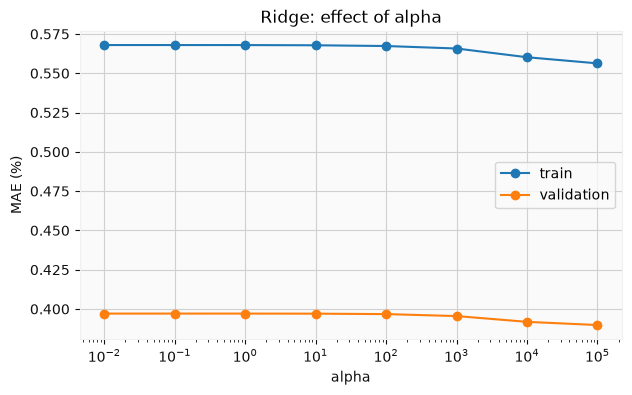

In [7]:
make_ridge = lambda alpha: make_pipeline(StandardScaler(), Ridge(alpha=alpha))
ridge_tuning = tune(make_ridge, {"alpha": [0.01, 0.1, 1, 10, 100, 1000, 10000, 100000]})
display(ridge_tuning)

plot_df = ridge_tuning.sort_values("alpha")
plt.figure(figsize=(7, 4))
plt.semilogx(plot_df["alpha"], plot_df["train_MAE"], "o-", label="train")
plt.semilogx(plot_df["alpha"], plot_df["val_MAE"], "o-", label="validation")
plt.xlabel("alpha"); plt.ylabel("MAE (%)"); plt.title("Ridge: effect of alpha"); plt.legend(); plt.show()

In [8]:
make_lasso = lambda alpha: make_pipeline(StandardScaler(), Lasso(alpha=alpha, max_iter=5000))
lasso_tuning = tune(make_lasso, {"alpha": [0.001, 0.01, 0.1, 1]})
display(lasso_tuning)

,alpha,train_MAE,val_MAE,val_DailyDirAcc,fit_s
0,0.100,0.556232,0.389694,0.497096,0.1
1,1.000,0.556242,0.389699,0.497096,0.1
2,0.010,0.562258,0.392952,0.484611,0.2
3,0.001,0.566902,0.396371,0.472706,2.0


In [9]:
best_ridge = fit_final(make_ridge, {"alpha": ridge_tuning.loc[0, "alpha"]})
report(f"Ridge (alpha={ridge_tuning.loc[0, 'alpha']})", yte, best_ridge.predict(Xte))

best_lasso = fit_final(make_lasso, {"alpha": lasso_tuning.loc[0, "alpha"]})
lasso_pred = best_lasso.predict(Xte)
report(f"Lasso (alpha={lasso_tuning.loc[0, 'alpha']})", yte, lasso_pred)
n_zero = (best_lasso[-1].coef_ == 0).sum()
print(f"Lasso set {n_zero} of {best_lasso[-1].coef_.size} coefficients exactly to zero")

Ridge (alpha=100000.0)       [test]  MAE=0.3264  RMSE=0.5029  HourDir=0.503  DayDir=0.524
Lasso (alpha=0.1)            [test]  MAE=0.3263  RMSE=0.5027  HourDir=0.507  DayDir=0.524
Lasso set 912 of 912 coefficients exactly to zero


## 5. k-Nearest Neighbors

Finds the `k` most similar past weeks and averages what happened the day after. Intuitive ("history rhymes"), no real training step. Feature scaling matters a lot here because it is distance-based. Note that with `weights="distance"` the train MAE is ~0 (each training point is its own nearest neighbour), so only the validation MAE is meaningful there.

| Hyperparameter | What it does | Values to try |
|---|---|---|
| `n_neighbors` | How many similar weeks to average. Small = noisy, large = smooth | 5, 20, 50, 100, 200 |
| `weights` | `uniform` treats all neighbours equally; `distance` gives closer ones more say | both |
| `p` | Distance metric: 1 = Manhattan, 2 = Euclidean | 1, 2 |

,n_neighbors,p,weights,train_MAE,val_MAE,val_DailyDirAcc,fit_s
0,200,2,distance,7.060418e-07,0.391237,0.477933,0.9
1,200,2,uniform,5.562931e-01,0.391238,0.477642,0.8
2,100,2,uniform,5.562582e-01,0.392852,0.472997,0.5
3,100,2,distance,3.658018e-07,0.392878,0.475319,0.6
4,50,2,uniform,5.556990e-01,0.396228,0.485192,0.4
5,50,2,distance,1.894043e-07,0.396258,0.486353,0.4
6,20,2,uniform,5.517667e-01,0.405485,0.486063,0.3
7,20,2,distance,7.891593e-08,0.405546,0.486353,0.3
8,5,2,uniform,5.146515e-01,0.443513,0.490999,0.5
9,5,2,distance,1.976736e-08,0.443544,0.489257,0.3


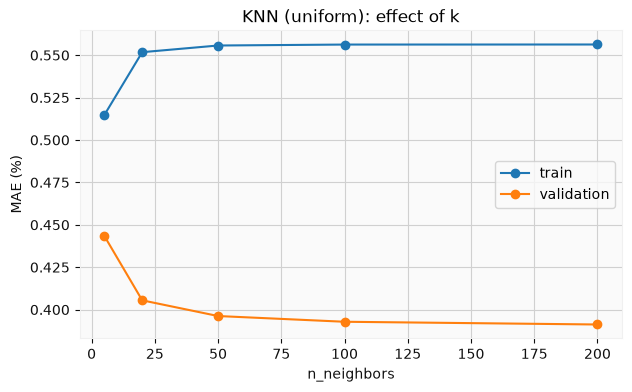

In [10]:
make_knn = lambda n_neighbors, weights, p: make_pipeline(
    StandardScaler(), KNeighborsRegressor(n_neighbors=n_neighbors, weights=weights, p=p))
knn_tuning = tune(make_knn, {"n_neighbors": [5, 20, 50, 100, 200],
                             "weights": ["uniform", "distance"], "p": [2]})
display(knn_tuning)

uni = knn_tuning[knn_tuning.weights == "uniform"].sort_values("n_neighbors")
plt.figure(figsize=(7, 4))
plt.plot(uni["n_neighbors"], uni["train_MAE"], "o-", label="train")
plt.plot(uni["n_neighbors"], uni["val_MAE"], "o-", label="validation")
plt.xlabel("n_neighbors"); plt.ylabel("MAE (%)"); plt.title("KNN (uniform): effect of k"); plt.legend(); plt.show()

In [11]:
p_knn = knn_tuning.loc[0, ["n_neighbors", "weights", "p"]].to_dict()
p_knn["n_neighbors"], p_knn["p"] = int(p_knn["n_neighbors"]), int(p_knn["p"])
best_knn = fit_final(make_knn, p_knn)
report(f"KNN {p_knn}", yte, best_knn.predict(Xte));

KNN {'n_neighbors': 200, 'weights': 'distance', 'p': 2} [test]  MAE=0.3281  RMSE=0.5042  HourDir=0.500  DayDir=0.494


## 6. Random Forest

Many decision trees trained on random subsets of the data, averaged together. Captures non-linear patterns and supports 24 outputs natively. No scaling needed.

| Hyperparameter | What it does | Values to try |
|---|---|---|
| `n_estimators` | Number of trees. More = more stable, slower; rarely hurts | 100, 200, 500 |
| `max_depth` | How deep each tree may grow. The main overfitting control | 5, 10, 20, None |
| `min_samples_leaf` | Minimum samples in a leaf; larger = smoother predictions | 1, 10, 50 |
| `max_features` | Fraction of features each split looks at; lower = more diverse trees | 0.3, 0.5, 1.0 |

Tip: deep trees with `min_samples_leaf=1` will have a train MAE far below validation MAE, a textbook overfitting example worth showing in the report.

In [12]:
make_rf = lambda **p: RandomForestRegressor(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, **p)
rf_tuning = tune(make_rf, {"max_depth": [5, 10, None],
                           "min_samples_leaf": [1, 50],
                           "max_features": [0.3, 1.0]})
display(rf_tuning)

,max_depth,max_features,min_samples_leaf,train_MAE,val_MAE,val_DailyDirAcc,fit_s
0,10.0,0.3,1,0.549967,0.389735,0.497096,2.0
1,10.0,1.0,1,0.550173,0.389738,0.497096,6.4
2,5.0,0.3,1,0.553070,0.389742,0.497096,1.5
3,5.0,1.0,1,0.553170,0.389751,0.497096,3.1
4,5.0,1.0,50,0.555930,0.389806,0.497096,2.9
5,10.0,1.0,50,0.555658,0.389811,0.497677,7.6
6,10.0,0.3,50,0.555500,0.389816,0.496806,1.9
7,5.0,0.3,50,0.555874,0.389846,0.497096,1.3
8,NaN,1.0,50,0.549217,0.390268,0.470093,30.4
9,NaN,0.3,50,0.549476,0.390297,0.472706,6.9


Random Forest {'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 0.3} [test]  MAE=0.3263  RMSE=0.5028  HourDir=0.507  DayDir=0.524


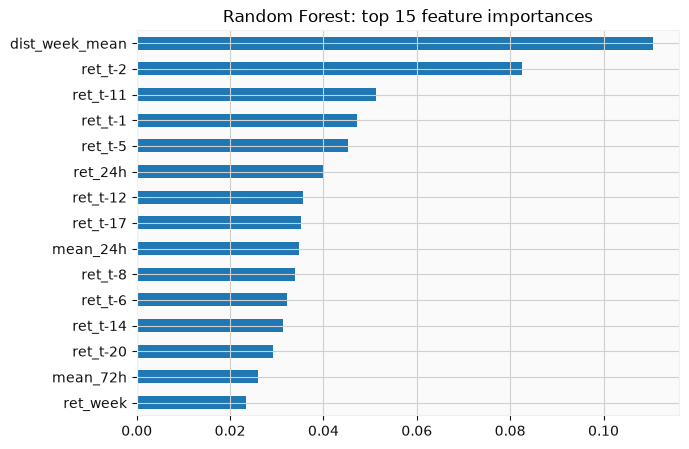

In [13]:
p_rf = rf_tuning.loc[0, ["max_depth", "min_samples_leaf", "max_features"]].to_dict()
p_rf["max_depth"] = None if pd.isna(p_rf["max_depth"]) else int(p_rf["max_depth"])
p_rf["min_samples_leaf"] = int(p_rf["min_samples_leaf"])
best_rf = RandomForestRegressor(n_estimators=300, n_jobs=-1, random_state=RANDOM_STATE, **p_rf).fit(Xtr_all, ytr_all)
report(f"Random Forest {p_rf}", yte, best_rf.predict(Xte))

if FEATURE_SET == "engineered":
    names = ([f"ret_t-{24 - i}" for i in range(24)] +
             ["mean_24h", "std_24h", "mean_72h", "std_72h", "mean_168h", "std_168h",
              "ret_24h", "ret_week", "pos_in_range", "dist_week_mean",
              "hl_range_24h", "hl_range_week", "vol_24h_vs_week", "vol_last_vs_week"])
    imp = pd.Series(best_rf.feature_importances_, index=names).sort_values()
    imp.tail(15).plot.barh(figsize=(7, 5), title="Random Forest: top 15 feature importances"); plt.show()

## 7. Gradient Boosting (HistGradientBoostingRegressor)

Trees built one after another, each one correcting the errors of the previous ones. Usually the strongest classical model on tabular data. It predicts one output at a time, so `MultiOutputRegressor` trains 24 separate models (one per future hour), which makes it the slowest model here; keep the grid small.

| Hyperparameter | What it does | Values to try |
|---|---|---|
| `learning_rate` | How much each new tree corrects. Smaller = needs more trees but generalises better | 0.03, 0.1 |
| `max_iter` | Number of boosting rounds (trees) | 100, 300 |
| `max_depth` / `max_leaf_nodes` | Complexity of each tree | 3, 5 / 15, 31 |
| `min_samples_leaf` | Smoothness, like in Random Forest | 20, 100 |
| `l2_regularization` | Penalty on leaf values | 0, 1 |
| `early_stopping` | Stop adding trees when an internal validation score stops improving | True |

In [14]:
make_hgb = lambda **p: MultiOutputRegressor(HistGradientBoostingRegressor(
    loss="absolute_error", early_stopping=True, random_state=RANDOM_STATE, **p))
hgb_tuning = tune(make_hgb, {"learning_rate": [0.03, 0.1],
                             "max_depth": [3, 5],
                             "max_iter": [200],
                             "min_samples_leaf": [100]})
display(hgb_tuning)

,learning_rate,max_depth,max_iter,min_samples_leaf,train_MAE,val_MAE,val_DailyDirAcc,fit_s
0,0.10,3,200,100,0.554560,0.389392,0.500000,2.0
1,0.03,5,200,100,0.553473,0.389392,0.498258,2.6
2,0.10,5,200,100,0.551552,0.389402,0.492160,2.4
3,0.03,3,200,100,0.554795,0.389403,0.497677,3.5


In [15]:
p_hgb = hgb_tuning.loc[0, ["learning_rate", "max_depth", "max_iter", "min_samples_leaf"]].to_dict()
p_hgb["learning_rate"] = float(p_hgb["learning_rate"])
for k in ("max_depth", "max_iter", "min_samples_leaf"):
    p_hgb[k] = int(p_hgb[k])
best_hgb = fit_final(make_hgb, p_hgb)
report(f"Gradient Boosting {p_hgb}", yte, best_hgb.predict(Xte));

Gradient Boosting {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 100} [test]  MAE=0.3262  RMSE=0.5027  HourDir=0.503  DayDir=0.520


## 8. (Optional) Small MLP from scikit-learn

A small, ready-made feed-forward neural network from scikit-learn: we only choose its size and settings, we do not build or code a network ourselves. Check with your teacher whether this fits the course rules; if not, skip this section.

| Hyperparameter | What it does | Values to try |
|---|---|---|
| `hidden_layer_sizes` | Neurons per layer | (32,), (64,), (64, 32) |
| `alpha` | L2 regularisation | 0.0001, 0.01, 1 |
| `learning_rate_init` | Step size of the optimiser | 0.001, 0.0001 |
| `early_stopping` | Stop when validation score stops improving | True |

In [16]:
make_mlp = lambda **p: make_pipeline(StandardScaler(), MLPRegressor(
    max_iter=200, early_stopping=True, random_state=RANDOM_STATE, **p))
mlp_tuning = tune(make_mlp, {"hidden_layer_sizes": [(32,), (64, 32)],
                             "alpha": [0.0001, 0.01, 1.0]})
display(mlp_tuning)

p_mlp = {"hidden_layer_sizes": mlp_tuning.loc[0, "hidden_layer_sizes"], "alpha": float(mlp_tuning.loc[0, "alpha"])}
best_mlp = fit_final(make_mlp, p_mlp)
report(f"MLP {p_mlp}", yte, best_mlp.predict(Xte));

,alpha,hidden_layer_sizes,train_MAE,val_MAE,val_DailyDirAcc,fit_s
0,1.0000,"(64, 32)",0.561583,0.393323,0.492451,1.5
1,0.0100,"(64, 32)",0.562211,0.393791,0.491870,1.6
2,0.0001,"(64, 32)",0.562269,0.393823,0.494483,1.4
3,1.0000,"(32,)",0.565846,0.396840,0.479675,1.0
4,0.0100,"(32,)",0.566884,0.397719,0.479094,1.0
5,0.0001,"(32,)",0.566914,0.397749,0.478804,1.3


MLP {'hidden_layer_sizes': (64, 32), 'alpha': 1.0} [test]  MAE=0.3289  RMSE=0.5050  HourDir=0.501  DayDir=0.506


## 9. More rigorous tuning: `TimeSeriesSplit` + `GridSearchCV`

Above, we tuned on a single validation period. Results can depend on which period that was. `TimeSeriesSplit` instead creates several train/validation splits that always move forward in time (never training on the future). The `gap` drops the windows right before each validation fold so overlapping windows do not leak information.

Here we tune Ridge this way as an example; the same pattern works for any model (replace the estimator and `param_grid`; use `RandomizedSearchCV` when the grid gets large).

In [17]:
gap = int(np.ceil((INPUT_HOURS + TARGET_HOURS) / STRIDE))
tscv = TimeSeriesSplit(n_splits=5, gap=gap)

search = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()),
    param_grid={"ridge__alpha": [0.1, 1, 10, 100, 1000, 10000]},
    cv=tscv, scoring="neg_mean_absolute_error", n_jobs=-1,
)
search.fit(Xtr_all, ytr_all)

cv_res = pd.DataFrame(search.cv_results_)[["param_ridge__alpha", "mean_test_score", "std_test_score"]]
cv_res["mean_val_MAE"] = -cv_res.pop("mean_test_score")
display(cv_res.sort_values("mean_val_MAE"))
print("Best:", search.best_params_)
report(f"Ridge (TS-CV, alpha={search.best_params_['ridge__alpha']})", yte, search.predict(Xte));

,param_ridge__alpha,std_test_score,mean_val_MAE
5,10000.0,0.063928,0.479433
4,1000.0,0.065474,0.486864
3,100.0,0.066632,0.490923
2,10.0,0.066998,0.492011
1,1.0,0.067094,0.492266
0,0.1,0.067107,0.492299


Best: {'ridge__alpha': 10000}
Ridge (TS-CV, alpha=10000)   [test]  MAE=0.3283  RMSE=0.5045  HourDir=0.500  DayDir=0.495


## 10. Final comparison on the test set

,Model,MAE,RMSE,HourlyDirAcc,DailyDirAcc
0,"Gradient Boosting {'learning_rate': 0.1, 'max_depth': 3, 'max_iter': 200, 'min_samples_leaf': 100}",0.3262,0.5027,0.503,0.520
1,Baseline: zero,0.3262,0.5027,0.493,0.476
2,Lasso (alpha=0.1),0.3263,0.5027,0.507,0.524
3,Baseline: mean per hour,0.3263,0.5027,0.507,0.524
4,"Random Forest {'max_depth': 10, 'min_samples_leaf': 1, 'max_features': 0.3}",0.3263,0.5028,0.507,0.524
5,Ridge (alpha=100000.0),0.3264,0.5029,0.503,0.524
6,"KNN {'n_neighbors': 200, 'weights': 'distance', 'p': 2}",0.3281,0.5042,0.500,0.494
7,"Ridge (TS-CV, alpha=10000)",0.3283,0.5045,0.500,0.495
8,"MLP {'hidden_layer_sizes': (64, 32), 'alpha': 1.0}",0.3289,0.5050,0.501,0.506
9,Baseline: persistence,0.4841,0.7144,0.498,0.485


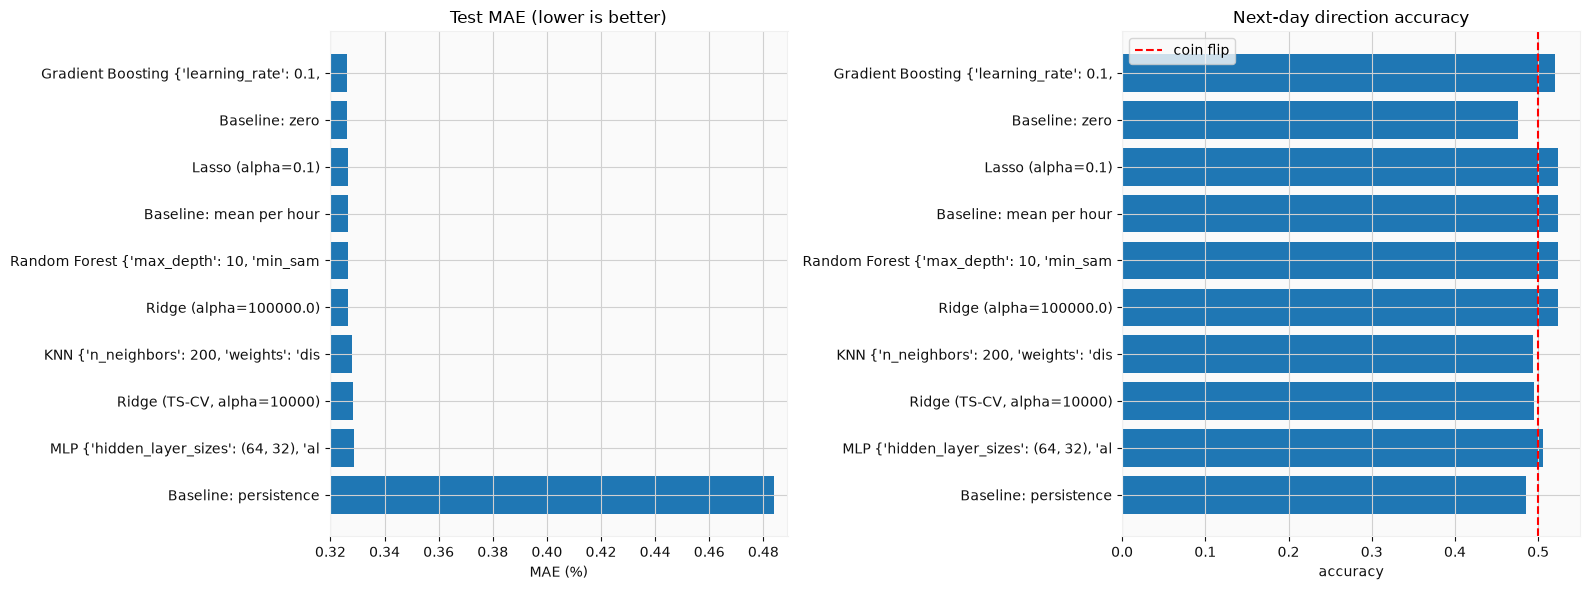

In [18]:
summary = (pd.DataFrame(results).query("Data == 'test'")
           .drop(columns="Data").drop_duplicates("Model", keep="last")
           .sort_values("MAE").reset_index(drop=True))
display(summary.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}",
                              "HourlyDirAcc": "{:.3f}", "DailyDirAcc": "{:.3f}"}))

labels = summary["Model"].str.slice(0, 40)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].barh(labels, summary["MAE"]); axes[0].invert_yaxis()
axes[0].set_xlabel("MAE (%)"); axes[0].set_title("Test MAE (lower is better)")
axes[0].set_xlim(summary["MAE"].min() * 0.98, summary["MAE"].max() * 1.01)
axes[1].barh(labels, summary["DailyDirAcc"]); axes[1].invert_yaxis()
axes[1].axvline(0.5, color="red", ls="--", label="coin flip")
axes[1].set_xlabel("accuracy"); axes[1].set_title("Next-day direction accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()

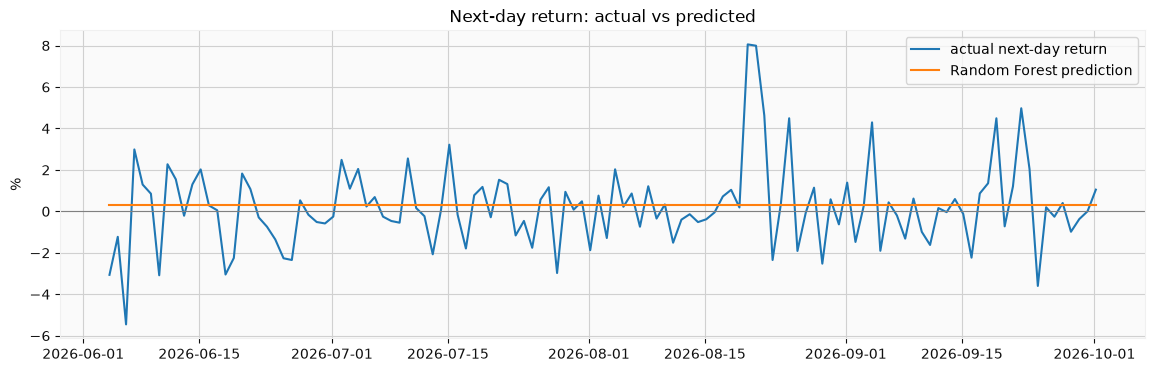

In [19]:
# Predicted vs actual next-day return for one model over the last ~120 test days
model_to_plot, name = best_rf, "Random Forest"
step = 24                                        # one non-overlapping window per day
sel = slice(-120 * step, None, step)
actual = daily_return(yte[sel])
pred = daily_return(model_to_plot.predict(Xte[sel]))

plt.figure(figsize=(14, 4))
plt.plot(dte[sel], actual, label="actual next-day return")
plt.plot(dte[sel], pred, label=f"{name} prediction")
plt.axhline(0, color="grey", lw=0.8)
plt.ylabel("%"); plt.title("Next-day return: actual vs predicted"); plt.legend(); plt.show()

## 11. Ideas for further experiments

Each of these is a small, one-line change that makes a good "what did we try" point in the report:

- Switch `FEATURE_SET` to `"returns_only"` and compare.
- Set `TRAIN_START = "2017-01-01"` (does old data help or hurt?).
- Change `STRIDE` (1 = all windows, slower; 24 = one per day, faster but less data).
- In Gradient Boosting, compare `loss="absolute_error"` vs `loss="squared_error"`.
- Simplify the target: predict only the **next-day total return** (one number) instead of 24 hourly values. Use `daily_return(ytr_all)` as `y`. Models then train 24× faster, and Gradient Boosting no longer needs `MultiOutputRegressor`.
- Turn it into a **classification** problem (will tomorrow go up or down?) with `LogisticRegression`, `RandomForestClassifier`, etc., and compare accuracy to 50%.

## 12. Conclusions (fill in)

- Best model on MAE: …
- Best model on direction accuracy: …
- Did any model clearly beat the baselines? …
- Which hyperparameters had the largest effect? …
- Signs of overfitting (train vs validation MAE): …